## Watch First: Build Visual Intuition

**Reference video:** [StatQuest: Convolutional Neural Networks (CNNs) Clearly Explained](https://www.youtube.com/watch?v=HGwBXDKFk9I)

Learning CNNs from notes alone can be very, very hard. Try watching this visual explanation first to build intuition for how images and filters work, then come back to these notes and take the Sobel mathematics and examples one step at a time.

# Detecting Image Edges with Mathematics

An **edge** is a place in an image where brightness or color changes quickly. Edges often outline objects, text, and other visual boundaries. We can find them by measuring how quickly pixel values change from one location to the next.

In this lesson, we will start with a tiny grayscale image and calculate the result of a 3 × 3 **Sobel filter** by hand. Then we will connect that calculation to larger grayscale photos and learn what changes when an image is RGB color.

### Learning goals

- Read a grayscale image as a matrix of brightness values.
- Multiply a 3 × 3 image patch by a filter and add the products.
- Use two Sobel filters to measure horizontal and vertical brightness changes.
- Combine the two measurements into edge strength and direction.
- Explain why RGB edge detection needs a decision about color channels.

### Start with one 3 × 3 image patch

Each number below is a pixel brightness from 0 (black) to 255 (white). This patch changes from dark on the left to bright on the right, so we expect a vertical boundary.

$$
P = \begin{bmatrix}
10 & 10 & 200 \\
10 & 10 & 200 \\
10 & 10 & 200
\end{bmatrix}
$$

A filter, also called a **kernel**, is another small matrix. We place it over the image patch, multiply values in matching positions, and add those products. The first visual below shows this patch alongside the two Sobel kernels.

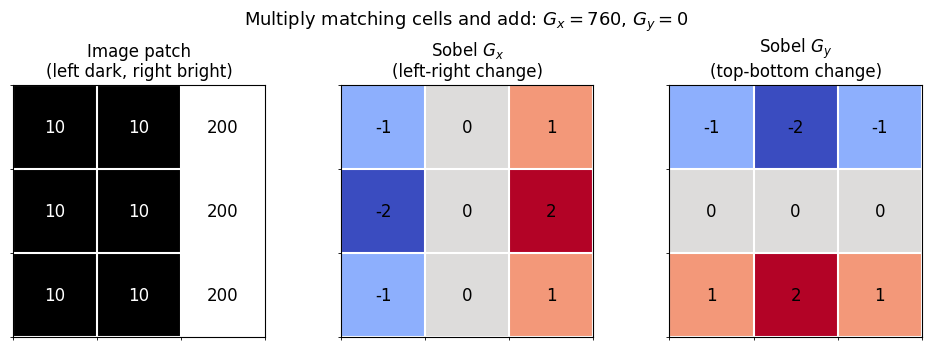

In [1]:
import matplotlib.pyplot as plt
import numpy as np

patch = np.array([[10, 10, 200], [10, 10, 200], [10, 10, 200]])
kernel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
kernel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
gradient_x = int(np.sum(patch * kernel_x))
gradient_y = int(np.sum(patch * kernel_y))

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
for ax, values, title, cmap in zip(
    axes,
    [patch, kernel_x, kernel_y],
    ["Image patch\n(left dark, right bright)", "Sobel $G_x$\n(left-right change)", "Sobel $G_y$\n(top-bottom change)"],
    ["gray", "coolwarm", "coolwarm"],
):
    limit = max(abs(values.min()), abs(values.max())) if "Sobel" in title else None
    ax.imshow(values, cmap=cmap, vmin=-limit if limit else None, vmax=limit if limit else None)
    for row in range(values.shape[0]):
        for column in range(values.shape[1]):
            ax.text(column, row, str(values[row, column]), ha="center", va="center", fontsize=12,
                    color="white" if values[row, column] < 20 and "Image" in title else "black")
    ax.set_title(title)
    ax.set_xticks(np.arange(-0.5, 3, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 3, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle(f"Multiply matching cells and add: $G_x={gradient_x}$, $G_y={gradient_y}$", fontsize=13)
fig.tight_layout()
plt.show()

## 1. Grayscale pixels and the Sobel calculation

A grayscale image can be written as a matrix $I[y,x]$. The row $y$ and column $x$ identify a pixel; its number is the pixel's brightness. In our patch, the left two columns are 10 and the right column is 200, so brightness jumps by 190 as we move to the right.

The Sobel operator uses two 3 × 3 kernels:

$$
K_x = \begin{bmatrix}-1&0&1\\-2&0&2\\-1&0&1\end{bmatrix}
\qquad
K_y = \begin{bmatrix}-1&-2&-1\\0&0&0\\1&2&1\end{bmatrix}
$$

For one patch, compute each response by multiplying corresponding cells and summing:

$$
G_x = \sum_{i=1}^{3}\sum_{j=1}^{3} P_{ij}(K_x)_{ij}
\qquad
G_y = \sum_{i=1}^{3}\sum_{j=1}^{3} P_{ij}(K_y)_{ij}
$$

For our patch, $G_x = 190 + 380 + 190 = 760$. The repeated rows cancel in $G_y$, so $G_y = 0$. The large $G_x$ says brightness changes strongly from left to right. That change happens across a **vertical edge**; the gradient points across the edge, not along it. The diagram's positive or negative sign depends on the chosen kernel convention, but edge strength uses the magnitude, so the sign does not affect the strength.

### See Sobel on a real grayscale image

These Wikimedia Commons images show a grayscale bicycle rack image and its Sobel results. The $x$ and $y$ outputs show directional brightness changes; the gradient-magnitude image combines them and makes strong changes bright.

### External example: grayscale image and Sobel maps

These externally hosted examples show a grayscale bicycle-rack photo, its $x$-gradient response, the combined gradient magnitude, and gradient direction. They make the difference between an edge's **strength** and its **direction** visible. The images require an internet connection.

<table>
<tr><th>Grayscale input</th><th>$x$-gradient response</th></tr>
<tr>
<td><img src="https://upload.wikimedia.org/wikipedia/commons/3/3f/Bikesgray.jpg" alt="Grayscale photograph of a brick wall and bike rack" width="320"></td>
<td><img src="https://upload.wikimedia.org/wikipedia/commons/6/60/Bikesgraygv.jpg" alt="Sobel x-gradient response for a bike rack image" width="320"></td>
</tr>
<tr><th>Gradient magnitude</th><th>Gradient direction</th></tr>
<tr>
<td><img src="https://upload.wikimedia.org/wikipedia/commons/1/17/Bikesgraysobel.jpg" alt="Combined Sobel gradient magnitude image of a bike rack" width="320"></td>
<td><img src="https://upload.wikimedia.org/wikipedia/commons/8/8b/Sobel_Operator_Gradient_Angle.JPG" alt="Color-coded directions of Sobel image gradients" width="320"></td>
</tr>
</table>

**Attribution:** The bike-rack image and its Sobel derivative are by Davidwkennedy, via [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Bikesgray.jpg), under [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/). See also the [gradient image file](https://commons.wikimedia.org/wiki/File:Bikesgraygv.jpg) and [Sobel result file](https://commons.wikimedia.org/wiki/File:Bikesgraysobel.jpg). The gradient-direction visual is by Max211, released into the [public domain](https://commons.wikimedia.org/wiki/File:Sobel_Operator_Gradient_Angle.JPG).

> Source images may use different display conventions for axis names and signs. The key ideas are that $G_x$ and $G_y$ measure changes along two perpendicular directions, magnitude combines their strengths, and direction describes the orientation of the change.

## 2. From two directional responses to an edge map

At every pixel, Sobel gives two values: $G_x$ and $G_y$. A large absolute value in either direction signals a rapid brightness change. To combine them into one direction-independent **edge strength**, use the Pythagorean formula:

$$
M = \sqrt{G_x^2 + G_y^2}
$$

For the patch above, $G_x=760$ and $G_y=0$, so $M=\sqrt{760^2+0^2}=760$. A flat area has values near zero; an edge has a larger value. The result $M$ at every image location forms a **gradient-magnitude image**.

The gradient also has a direction:

$$
\theta = \operatorname{atan2}(G_y, G_x)
$$

This angle points in the direction of greatest brightness increase. It is perpendicular to the edge line itself. Direction can help distinguish, for example, a vertical boundary from a horizontal one.

An edge detector often **normalizes** magnitudes so they fit a display range such as 0–255, then may apply a **threshold**: values above the chosen cutoff are shown as edges. A low threshold keeps faint details but may include noise; a high threshold gives fewer, stronger edges but can lose subtle boundaries. Sobel gives a useful estimate, not a perfect outline of every object.

### Padding: what happens at the border?

A filter needs a complete window of pixels for every calculation. Without padding, the 3 × 3 filter cannot be centered on the outermost border, so the output becomes smaller. **Padding** adds extra values around the image before filtering. A common choice is zero padding: add a border of zero-valued pixels. With a 3 × 3 filter and one pixel of padding on each side, a 5 × 5 image can produce a 5 × 5 output. The border is retained in the result, although padded zeros are artificial values and may affect edge responses near the boundary.

### Stride: how far does the filter move?

**Stride** is the number of pixels the filter moves each time. Stride 1 checks every neighboring position and creates overlapping windows. Stride 2 moves two pixels at a time, skipping positions and producing a smaller output. Larger stride is faster and downsamples the result, but can miss fine details.

For an image side length $N$, filter side length $K$, padding $P$, and stride $S$, the output side length is:

$$
\left\lfloor \frac{N + 2P - K}{S} \right\rfloor + 1
$$

For example, with a 5 × 5 image and a 3 × 3 filter: no padding and stride 1 gives a 3 × 3 output; padding 1 and stride 1 gives 5 × 5; padding 1 and stride 2 gives 3 × 3. Padding controls how borders are handled; stride controls how densely the filter samples positions.

The next figure compares these output sizes and highlights why padding helps preserve borders while stride reduces the number of sampled positions.

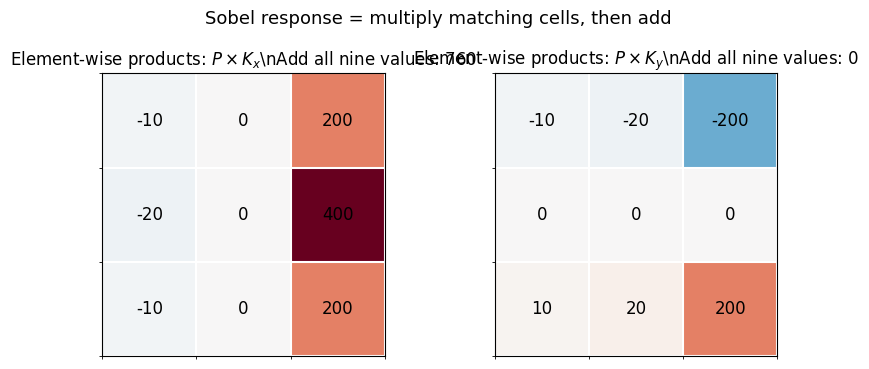

In [2]:
import matplotlib.pyplot as plt
import numpy as np

patch = np.array([[10, 10, 200], [10, 10, 200], [10, 10, 200]])
kernel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
kernel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
products = [patch * kernel_x, patch * kernel_y]
responses = [int(products[0].sum()), int(products[1].sum())]

fig, axes = plt.subplots(1, 2, figsize=(8, 3.7))
for ax, values, label, response in zip(axes, products, ["$P \\times K_x$", "$P \\times K_y$"], responses):
    ax.imshow(values, cmap="RdBu_r", vmin=-400, vmax=400)
    for row in range(3):
        for column in range(3):
            ax.text(column, row, str(values[row, column]), ha="center", va="center", fontsize=12)
    ax.set_title(f"Element-wise products: {label}\\nAdd all nine values: {response}")
    ax.set_xticks(np.arange(-0.5, 3, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 3, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Sobel response = multiply matching cells, then add", fontsize=13)
fig.tight_layout()
plt.show()

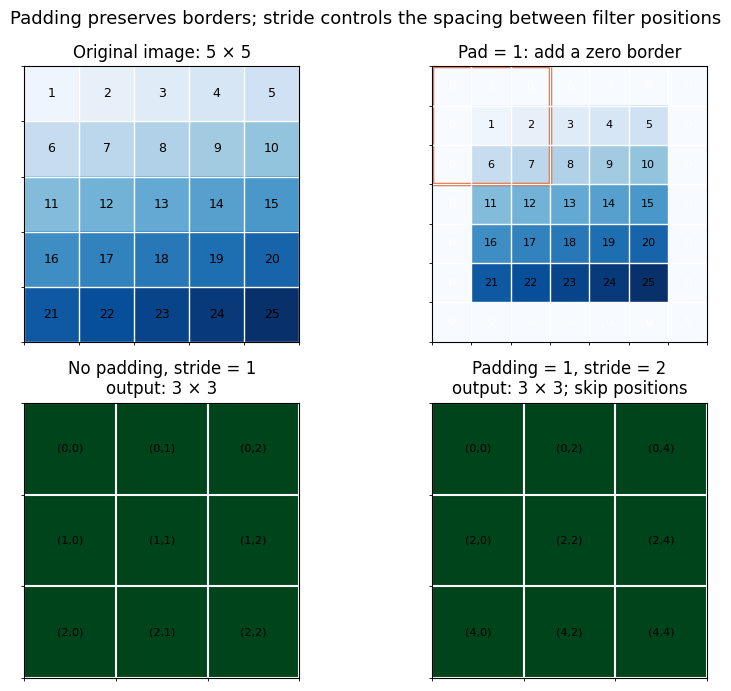

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

image = np.arange(1, 26).reshape(5, 5)
padded = np.pad(image, pad_width=1, mode="constant", constant_values=0)

fig, axes = plt.subplots(2, 2, figsize=(9, 7))
image_ax, padded_ax, valid_ax, stride_ax = axes.ravel()

image_ax.imshow(image, cmap="Blues", vmin=0, vmax=25)
for row in range(5):
    for column in range(5):
        image_ax.text(column, row, str(image[row, column]), ha="center", va="center", fontsize=9)
image_ax.set_title("Original image: 5 × 5")

padded_ax.imshow(padded, cmap="Blues", vmin=0, vmax=25)
for row in range(7):
    for column in range(7):
        value = padded[row, column]
        padded_ax.text(column, row, str(value) if value else "0", ha="center", va="center", fontsize=8,
                       color="white" if value == 0 else "black")
padded_ax.add_patch(Rectangle((-0.5, -0.5), 3, 3, fill=False, edgecolor="#D76737", linewidth=2.5))
padded_ax.set_title("Pad = 1: add a zero border")

for ax, size, title, spacing in [
    (valid_ax, 3, "No padding, stride = 1\noutput: 3 × 3", 1),
    (stride_ax, 3, "Padding = 1, stride = 2\noutput: 3 × 3; skip positions", 2),
]:
    ax.imshow(np.ones((size, size)), cmap="Greens", vmin=0, vmax=1)
    for row in range(size):
        for column in range(size):
            ax.text(column, row, f"({row * spacing},{column * spacing})", ha="center", va="center", fontsize=8)
    ax.set_title(title)
    ax.set_xticks(np.arange(-0.5, size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, size, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.set_xticks([])
    ax.set_yticks([])

for ax in [image_ax, padded_ax]:
    width = ax.images[0].get_array().shape[1]
    height = ax.images[0].get_array().shape[0]
    ax.set_xticks(np.arange(-0.5, width, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, height, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Padding preserves borders; stride controls the spacing between filter positions", fontsize=13)
fig.tight_layout()
plt.show()

## 3. Pooling: summarize nearby responses

After convolution, a CNN may use **pooling** to shrink a feature map. A pooling window looks at a small group of nearby values and replaces them with one summary value. Pooling is usually applied separately to each feature channel, so it reduces height and width but does not mix channels.

- **Max pooling** keeps the largest value in each window. It preserves the strongest detected response in that neighborhood.
- **Average pooling** replaces each window with its mean. It smooths responses by summarizing all the values.

For a 4 × 4 feature map, 2 × 2 pooling with stride 2 makes four non-overlapping regions and produces a 2 × 2 result. For max pooling, the top-left region `[[1, 3], [2, 9]]` becomes `9`; for average pooling it becomes `(1 + 3 + 2 + 9) / 4 = 3.75`.

Pooling has no learned filter weights: it applies a fixed summary rule. It reduces the amount of spatial detail and later computation, but too much pooling can erase small features. The example below computes both max and average pooling on the same feature map.

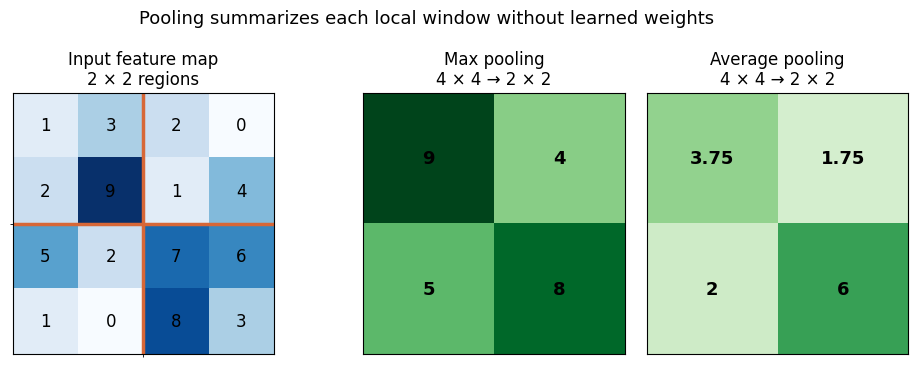

In [5]:
import matplotlib.pyplot as plt
import numpy as np

feature_map = np.array([
    [1, 3, 2, 0],
    [2, 9, 1, 4],
    [5, 2, 7, 6],
    [1, 0, 8, 3],
])
max_pooled = np.array([[feature_map[row:row + 2, column:column + 2].max()
                        for column in range(0, 4, 2)] for row in range(0, 4, 2)])
average_pooled = np.array([[feature_map[row:row + 2, column:column + 2].mean()
                            for column in range(0, 4, 2)] for row in range(0, 4, 2)])

fig, axes = plt.subplots(1, 3, figsize=(10, 3.7), gridspec_kw={"width_ratios": [1.2, 0.8, 0.8]})
axes[0].imshow(feature_map, cmap="Blues", vmin=0, vmax=9)
for row in range(4):
    for column in range(4):
        axes[0].text(column, row, str(feature_map[row, column]), ha="center", va="center", fontsize=12)
axes[0].set_title("Input feature map\n2 × 2 regions")
axes[0].set_xticks([1.5], minor=True)
axes[0].set_yticks([1.5], minor=True)
axes[0].grid(which="minor", color="#D76737", linewidth=2.5)
axes[0].set_xticks([])
axes[0].set_yticks([])

for ax, values, title in zip(axes[1:], [max_pooled, average_pooled], ["Max pooling", "Average pooling"]):
    ax.imshow(values, cmap="Greens", vmin=0, vmax=9)
    for row in range(2):
        for column in range(2):
            ax.text(column, row, f"{values[row, column]:g}", ha="center", va="center", fontsize=13, weight="bold")
    ax.set_title(title + "\n4 × 4 → 2 × 2")
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Pooling summarizes each local window without learned weights", fontsize=13)
fig.tight_layout()
plt.show()

## 4. What changes for RGB images?

A color image has three values at each pixel: **red, green, and blue**. Its shape is often written as `(height, width, 3)`. A Sobel kernel is still 3 × 3 in space, but each location now has three channel values. There are two common approaches:

1. **Convert to grayscale, then apply Sobel.** A common brightness approximation is $Y = 0.299R + 0.587G + 0.114B$. Then apply the same $K_x$ and $K_y$ kernels to the single brightness channel. This is simple and works well when edges correspond to brightness changes.
2. **Detect changes in the color channels.** Apply Sobel to R, G, and B separately, then combine their responses. One possible strength measure is $M = \sqrt{G_{x,R}^2 + G_{y,R}^2 + G_{x,G}^2 + G_{y,G}^2 + G_{x,B}^2 + G_{y,B}^2}$. This can keep a color boundary even when its two sides have similar grayscale brightness.

Which method is best depends on the task. Grayscale processing is simpler; channel-wise processing can preserve more color-boundary information. Real systems also need to consider noise and choose sensible normalization and thresholds.

### External example: a color image and its edge result

This Wikimedia Commons pair shows a color photograph of a museum valve and an edge-detected result. It provides a real-image comparison alongside the grayscale Sobel maps above. The paired result is an external example; results can vary with the exact filter and settings used.

<table>
<tr><th>Color input</th><th>Edge-detected result</th></tr>
<tr>
<td><img src="https://upload.wikimedia.org/wikipedia/commons/f/f0/Valve_original_%281%29.PNG" alt="Color photograph of a valve at a museum" width="320"></td>
<td><img src="https://upload.wikimedia.org/wikipedia/commons/d/d4/Valve_sobel_%283%29.PNG" alt="Edge-detected view of the museum valve" width="320"></td>
</tr>
</table>

**Attribution:** Both images are by Simpsons contributor, via Wikimedia Commons: [original color image](https://commons.wikimedia.org/wiki/File:Valve_original_(1).PNG) and [edge-detected image](https://commons.wikimedia.org/wiki/File:Valve_sobel_(3).PNG), licensed under [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/).

### A tiny color-edge calculation

Imagine every pixel in the left two columns is red `(100, 0, 0)` and every pixel in the right column is green `(0, 51, 0)`. Their approximate grayscale brightnesses are both about 30, because $0.299(100) \approx 0.587(51)$. If grayscale values are rounded to whole numbers, the boundary disappears. The RGB channels still change strongly, so channel-wise Sobel can detect it.

The next figure compares the rounded grayscale patch with the color input and shows the directional response from each approach. The response scales differ because one combines three channels; the important point is that converting to grayscale can hide some color-only boundaries.

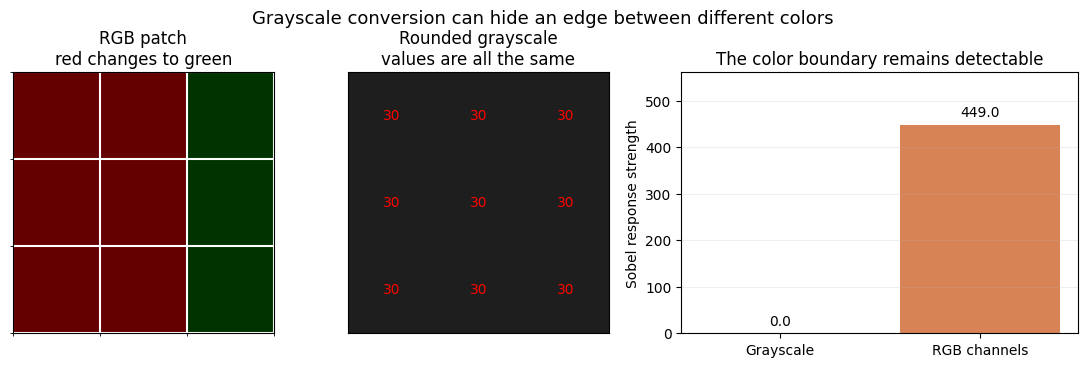

In [3]:
import matplotlib.pyplot as plt
import numpy as np

kernel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
kernel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
rgb_patch = np.zeros((3, 3, 3), dtype=np.uint8)
rgb_patch[:, :2, 0] = 100
rgb_patch[:, 2, 1] = 51
rgb_float = rgb_patch.astype(float)
gray_patch = np.rint(0.299 * rgb_float[:, :, 0] + 0.587 * rgb_float[:, :, 1] + 0.114 * rgb_float[:, :, 2]).astype(int)
gray_gx = float(np.sum(gray_patch * kernel_x))
gray_gy = float(np.sum(gray_patch * kernel_y))
gray_strength = np.hypot(gray_gx, gray_gy)
channel_gradients = [(float(np.sum(rgb_float[:, :, channel] * kernel_x)),
                      float(np.sum(rgb_float[:, :, channel] * kernel_y))) for channel in range(3)]
rgb_strength = float(np.sqrt(sum(gx ** 2 + gy ** 2 for gx, gy in channel_gradients)))

fig, axes = plt.subplots(1, 3, figsize=(11, 3.7), gridspec_kw={"width_ratios": [1, 1, 1.5]})
axes[0].imshow(rgb_patch, interpolation="nearest")
axes[0].set_title("RGB patch\nred changes to green")
axes[0].set_xticks(np.arange(-0.5, 3, 1), minor=True)
axes[0].set_yticks(np.arange(-0.5, 3, 1), minor=True)
axes[0].grid(which="minor", color="white", linewidth=1.5)
axes[0].set_xticks([])
axes[0].set_yticks([])

axes[1].imshow(gray_patch, cmap="gray", vmin=0, vmax=255)
for row in range(3):
    for column in range(3):
        axes[1].text(column, row, str(gray_patch[row, column]), ha="center", va="center", color="red" if gray_patch[row, column] < 128 else "black")
axes[1].set_title("Rounded grayscale\nvalues are all the same")
axes[1].set_xticks([])
axes[1].set_yticks([])

bars = axes[2].bar(["Grayscale", "RGB channels"], [gray_strength, rgb_strength], color=["#4B83B4", "#D88355"])
axes[2].set_ylabel("Sobel response strength")
axes[2].set_title("The color boundary remains detectable")
axes[2].set_ylim(0, rgb_strength * 1.25)
for bar, value in zip(bars, [gray_strength, rgb_strength]):
    axes[2].text(bar.get_x() + bar.get_width() / 2, value + rgb_strength * 0.025,
                 f"{value:.1f}", ha="center", va="bottom", fontsize=10)
axes[2].grid(axis="y", alpha=0.2)
fig.suptitle("Grayscale conversion can hide an edge between different colors", fontsize=13)
fig.tight_layout()
plt.show()

## 5. Sobel filters and CNN filters: an important difference

Both Sobel and CNN convolution layers slide small filters across an image and combine pixel values with filter weights. The difference is where those weights come from:

- **Sobel:** the two 3 × 3 kernels are fixed by a human-designed formula. They estimate brightness change in two directions.
- **CNN:** filters usually begin with learned or initialized weights and are adjusted during training to help solve a task. They may respond to edges, textures, colors, or more complex patterns.

So Sobel is a useful way to understand the multiply-and-add mechanics of a convolution, but applying Sobel is not the same as training a CNN. It is a fixed edge detector.

### Recap

- Grayscale images can be represented as matrices of brightness values.
- A 3 × 3 filter response is the sum of nine element-wise products between a filter and the matching image patch.
- Sobel uses $K_x$ and $K_y$ to estimate brightness changes in perpendicular directions.
- $M = \sqrt{G_x^2 + G_y^2}$ combines those responses into edge strength; $\theta = \operatorname{atan2}(G_y,G_x)$ gives gradient direction.
- **Padding** adds a border so filters can process image edges; **stride** sets how far the filter moves between positions.
- **Pooling** summarizes neighboring feature-map values, commonly with a maximum or average, and reduces spatial size.
- RGB edge detection can use grayscale brightness or combine responses from individual color channels.
- Sobel uses fixed filters; CNN filters are generally learned from data.

### Check your understanding

1. In the 3 × 3 example, why is $G_x$ large while $G_y$ is zero?
2. Does the gradient direction point along an edge or across it?
3. With a 5 × 5 image, a 3 × 3 filter, stride 1, and no padding, what is the output size? What if padding is 1?
4. What happens to the output size when stride increases from 1 to 2?
5. What is the difference between max pooling and average pooling?
6. Why might a color boundary disappear after converting to grayscale?
7. What is the key difference between a Sobel kernel and a CNN filter?

<details>
<summary>Show suggested answers</summary>

1. Brightness changes from left to right, but stays constant from top to bottom.
2. Across the edge, in the direction of greatest brightness change.
3. No padding gives 3 × 3; padding 1 gives 5 × 5.
4. The filter samples fewer positions, so the output usually becomes smaller.
5. Max pooling keeps the largest value in each window; average pooling computes its mean.
6. Different colors can have nearly equal grayscale brightness, so the conversion can remove their contrast.
7. Sobel kernels are fixed formulas; CNN filters are usually learned by training on data.

</details>